# Tugas Praktikum 2: Praproses Data

**Nama:** Muhammad Rafie Safaraz Barus
**NRP:** 5054251014

Dataset: [House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data?select=train.csv) (`train.csv`)

## 1. Import Library dan Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.shape

(1460, 81)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

Dataset berisi 1460 baris dan 81 kolom, terdiri dari 38 kolom numerik dan 43 kolom kategorikal. Target yang akan diprediksi adalah `SalePrice`.

## 2. Pembersihan Data

### 2.1 Cek Nilai yang Hilang

In [5]:
missing = df.isnull().sum()
persen = missing / len(df) * 100

data_missing = pd.DataFrame({'Jumlah': missing, 'Persen (%)': persen.round(2)})
data_missing = data_missing[data_missing['Jumlah'] > 0].sort_values('Jumlah', ascending=False)
data_missing

,Jumlah,Persen (%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


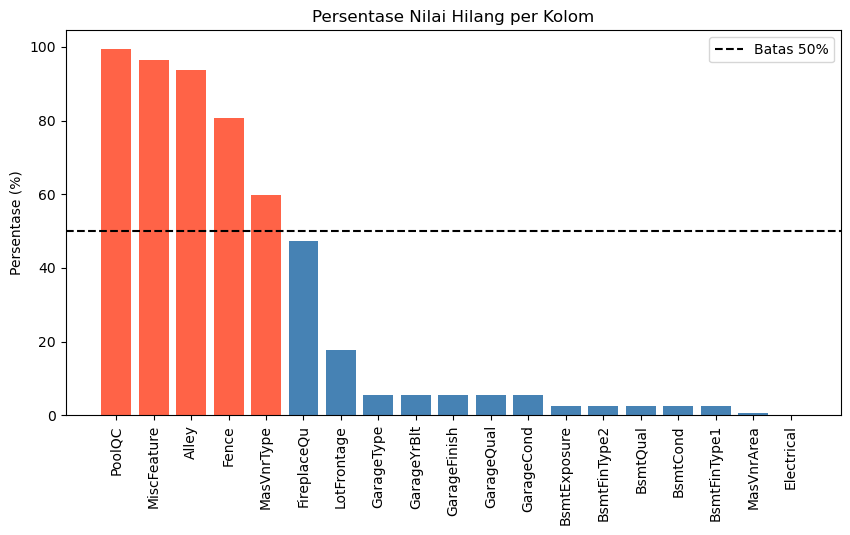

In [6]:
warna = ['tomato' if p > 50 else 'steelblue' for p in data_missing['Persen (%)']]

plt.figure(figsize=(10, 5))
plt.bar(data_missing.index, data_missing['Persen (%)'], color=warna)
plt.axhline(50, color='black', linestyle='--', label='Batas 50%')
plt.xticks(rotation=90)
plt.ylabel('Persentase (%)')
plt.title('Persentase Nilai Hilang per Kolom')
plt.legend()
plt.show()

Ada 19 kolom yang memiliki nilai hilang. Lima kolom di antaranya nilai hilangnya lebih dari 50%, yaitu `PoolQC`, `MiscFeature`, `Alley`, `Fence`, dan `MasVnrType`.

### 2.2 Hapus Kolom dengan Nilai Hilang > 50%

In [7]:
kolom_hapus = data_missing[data_missing['Persen (%)'] > 50].index
print(list(kolom_hapus))

df = df.drop(columns=kolom_hapus)
df = df.drop(columns='Id')
df.shape

['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']


(1460, 75)

Kolom `Id` juga dihapus karena hanya nomor urut dan tidak berpengaruh ke harga rumah.

### 2.3 Menangani Nilai Hilang Lainnya

Menurut `data_description.txt`, nilai NA pada kolom `Garage*`, `Bsmt*`, dan `FireplaceQu` artinya rumah tersebut **tidak punya** garasi, basement, atau perapian. Jadi nilai hilangnya bukan data yang kosong, melainkan kategori tersendiri. Cara penanganannya:
- Kolom kategorikal diisi `'None'`, kecuali `Electrical` (hanya 1 data hilang) yang diisi modus.
- `GarageYrBlt` diisi dengan `YearBuilt`, karena biasanya garasi dibangun bersamaan dengan rumahnya.
- Kolom numerik lain (`LotFrontage`, `MasVnrArea`) diisi median karena median tidak terpengaruh outlier.

In [8]:
kolom_kategori = df.select_dtypes(exclude='number').columns
kolom_numerik = df.select_dtypes(include='number').columns

df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])
df[kolom_kategori] = df[kolom_kategori].fillna('None')
df[kolom_numerik] = df[kolom_numerik].fillna(df[kolom_numerik].median())

print('Total nilai hilang:', df.isnull().sum().sum())

Total nilai hilang: 0


### 2.4 Cek Duplikat dan Data Tidak Konsisten

In [9]:
print('Data duplikat:', df.duplicated().sum())
print('Tahun renovasi < tahun dibangun:', (df['YearRemodAdd'] < df['YearBuilt']).sum())
print('Tahun dibangun > tahun terjual:', (df['YearBuilt'] > df['YrSold']).sum())

Data duplikat: 0
Tahun renovasi < tahun dibangun: 0
Tahun dibangun > tahun terjual: 0


In [10]:
print(df['MSSubClass'].unique())
df['MSSubClass'] = df['MSSubClass'].astype(str)

[ 60  20  70  50 190  45  90 120  30  85  80 160  75 180  40]


Tidak ada data duplikat dan tidak ada tahun yang tidak masuk akal. Kolom `MSSubClass` bertipe angka, padahal isinya kode tipe bangunan (20, 60, 70, dst.) sehingga harus diperlakukan sebagai kategori. Karena itu tipenya diubah menjadi string supaya nanti ikut di-*encode*.

## 3. Deteksi dan Penanganan Outlier

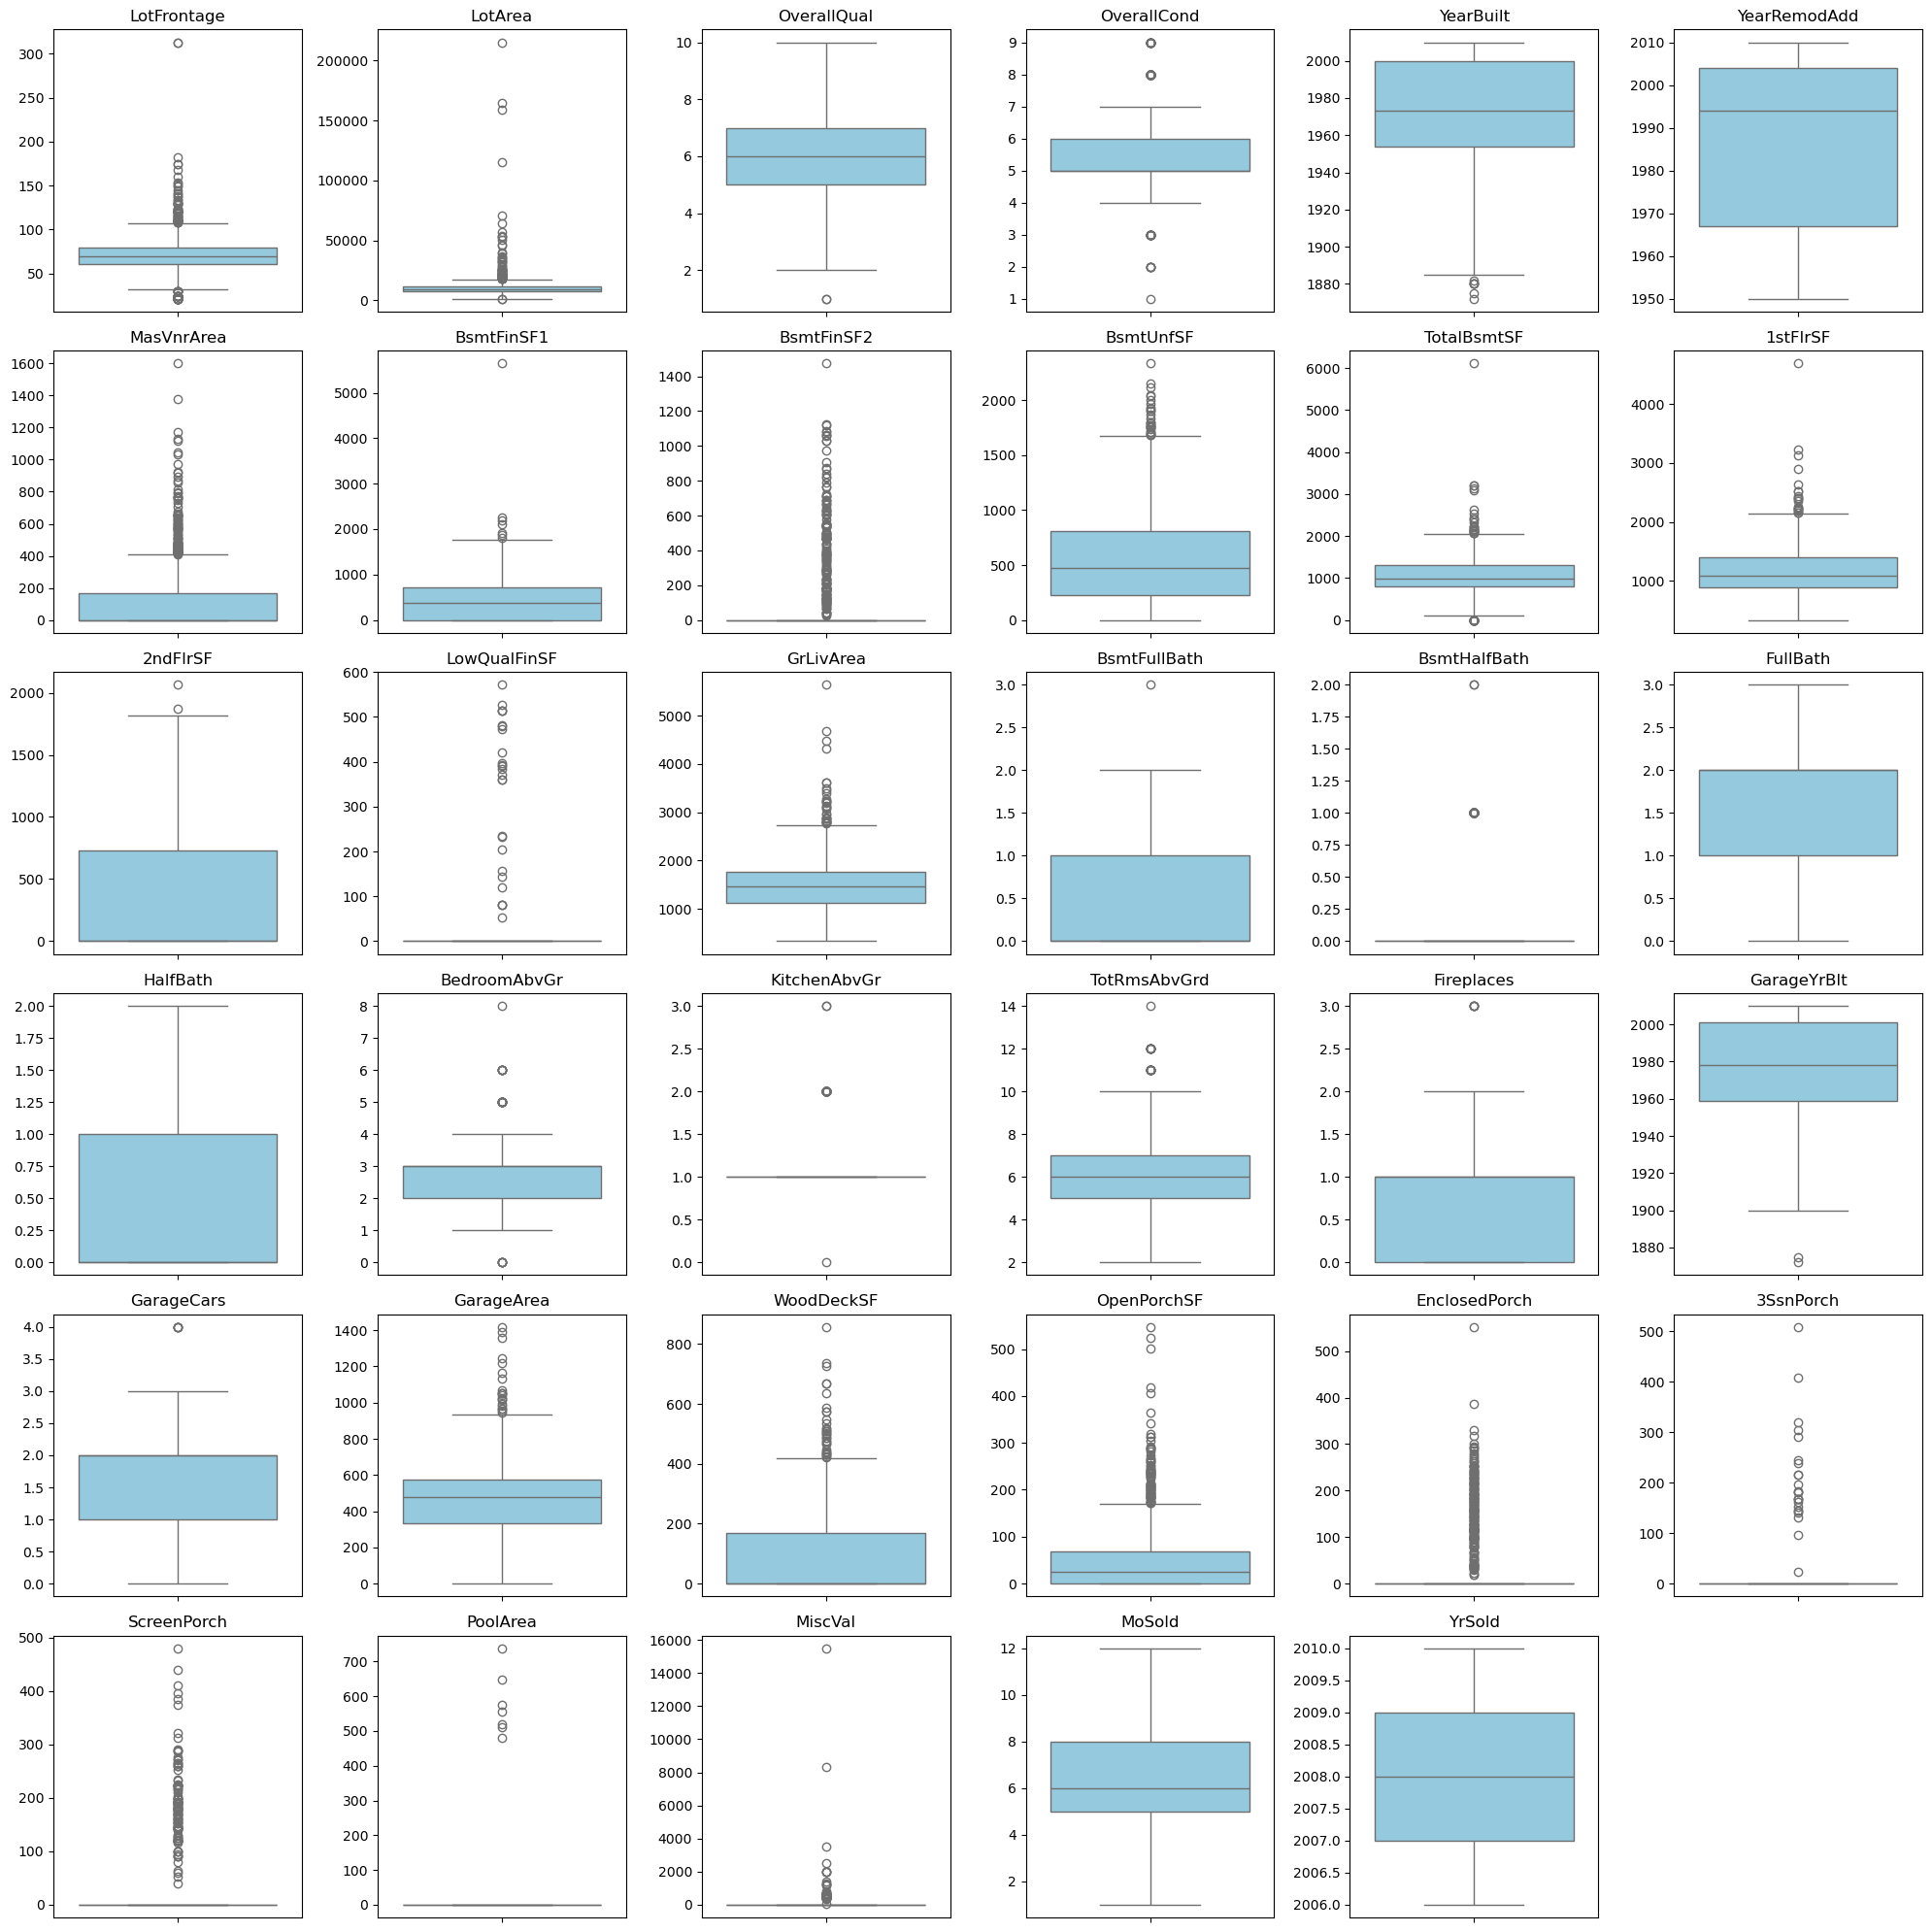

In [11]:
kolom_numerik = df.select_dtypes(include='number').columns.drop('SalePrice')

plt.figure(figsize=(20, 20))
for i, kolom in enumerate(kolom_numerik):
    plt.subplot(6, 6, i + 1)
    sns.boxplot(y=df[kolom], color='skyblue')
    plt.title(kolom)
    plt.ylabel('')
plt.tight_layout()
plt.show()

In [12]:
Q1 = df[kolom_numerik].quantile(0.25)
Q3 = df[kolom_numerik].quantile(0.75)
IQR = Q3 - Q1
outlier = (df[kolom_numerik] < Q1 - 1.5 * IQR) | (df[kolom_numerik] > Q3 + 1.5 * IQR)

print('Jumlah baris yang punya outlier:', outlier.any(axis=1).sum())
outlier.sum().sort_values(ascending=False)

Jumlah baris yang punya outlier: 872


EnclosedPorch    208
BsmtFinSF2       167
OverallCond      125
ScreenPorch      116
LotFrontage      106
MasVnrArea        98
BsmtHalfBath      82
OpenPorchSF       77
LotArea           69
KitchenAbvGr      68
TotalBsmtSF       61
MiscVal           52
BedroomAbvGr      35
WoodDeckSF        32
GrLivArea         31
TotRmsAbvGrd      30
BsmtUnfSF         29
LowQualFinSF      26
3SsnPorch         24
GarageArea        21
1stFlrSF          20
YearBuilt          7
PoolArea           7
BsmtFinSF1         7
GarageCars         5
Fireplaces         5
OverallQual        2
2ndFlrSF           2
GarageYrBlt        2
BsmtFullBath       1
YearRemodAdd       0
HalfBath           0
FullBath           0
MoSold             0
YrSold             0
dtype: int64

Dari boxplot dan perhitungan IQR, hampir semua atribut numerik memiliki outlier. Jika semua baris yang mengandung outlier dihapus, 872 dari 1460 data (±60%) akan hilang, sehingga outlier tidak bisa dihapus semuanya. Keputusan yang diambil:

1. **Dihapus** – hanya rumah yang benar-benar anomali, yaitu `GrLivArea` > 4000 tetapi `SalePrice` < 300.000 (rumah sangat besar tapi harganya murah). Datanya hanya 2 baris dan terlihat jelas menyimpang pada scatter plot di bawah.
2. **Disesuaikan (capping)** – atribut luas yang kontinu (`LotArea`, `GrLivArea`, `TotalBsmtSF`, dll.). Nilai di luar batas IQR diganti dengan batas bawah/atas, sehingga datanya tidak hilang.
3. **Dibiarkan** – atribut diskrit (`OverallCond`, `BedroomAbvGr`, `KitchenAbvGr`, dll.), atribut tahun, dan atribut yang mayoritas nilainya 0 (`PoolArea`, `ScreenPorch`, `EnclosedPorch`, `MiscVal`, dll.). Outlier pada atribut ini adalah nilai yang wajar, misalnya rumah yang punya kolam renang. Pada atribut yang mayoritas 0, IQR-nya juga 0, jadi kalau di-capping semua nilainya akan berubah menjadi 0.
4. `SalePrice` tidak diubah karena merupakan target.

In [13]:
anomali = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]
anomali[['GrLivArea', 'SalePrice', 'SaleCondition']]

,GrLivArea,SalePrice,SaleCondition
523,4676,184750,Partial
1298,5642,160000,Partial


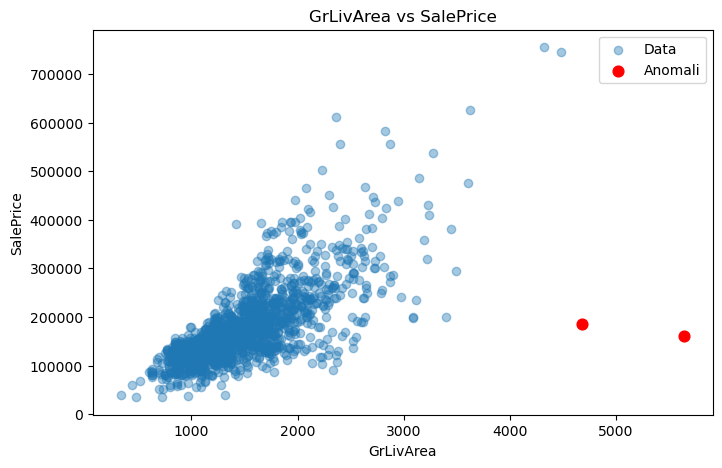

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.4, label='Data')
plt.scatter(anomali['GrLivArea'], anomali['SalePrice'], color='red', s=60, label='Anomali')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.title('GrLivArea vs SalePrice')
plt.legend()
plt.show()

In [15]:
df = df.drop(anomali.index)
df.shape

(1458, 75)

In [16]:
kolom_capping = ['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF',
                 '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF']

Q1 = df[kolom_capping].quantile(0.25)
Q3 = df[kolom_capping].quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

sebelum = df[kolom_capping].copy()
df[kolom_capping] = df[kolom_capping].clip(lower=batas_bawah, upper=batas_atas, axis=1)

print('Jumlah nilai yang di-capping:')
print(((sebelum < batas_bawah) | (sebelum > batas_atas)).sum())

Jumlah nilai yang di-capping:
LotFrontage    104
LotArea         66
MasVnrArea      97
BsmtFinSF1       5
BsmtUnfSF       29
TotalBsmtSF     59
1stFlrSF        18
2ndFlrSF         2
GrLivArea       29
GarageArea      20
WoodDeckSF      32
OpenPorchSF     75
dtype: int64


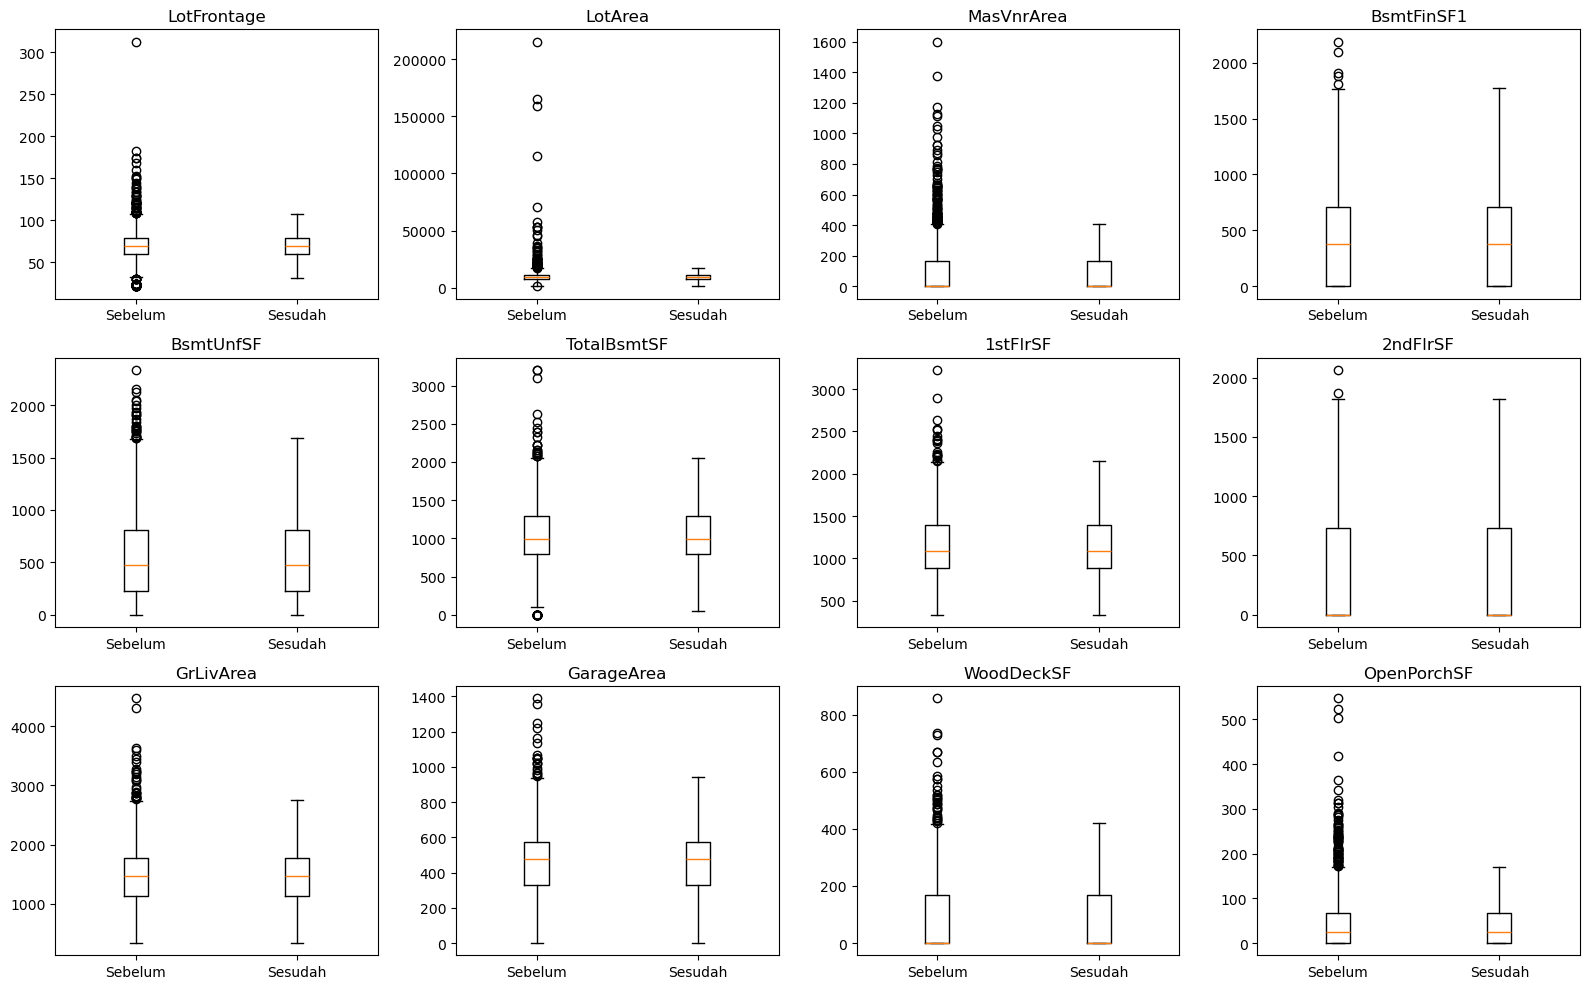

In [17]:
plt.figure(figsize=(16, 10))
for i, kolom in enumerate(kolom_capping):
    plt.subplot(3, 4, i + 1)
    plt.boxplot([sebelum[kolom], df[kolom]])
    plt.xticks([1, 2], ['Sebelum', 'Sesudah'])
    plt.title(kolom)
plt.tight_layout()
plt.show()

Setelah capping, atribut-atribut tersebut sudah tidak memiliki outlier di luar batas IQR, dan jumlah data tetap 1458 baris.

## 4. Transformasi Data

### 4.1 Standarisasi

Standarisasi dilakukan menggunakan `StandardScaler` (z-score) sehingga setiap atribut numerik memiliki mean 0 dan standar deviasi 1. Standarisasi dipilih karena skala antar atribut sangat berbeda (misalnya `LotArea` ribuan, `OverallQual` 1–10), dan PCA di tahap berikutnya sensitif terhadap skala. `SalePrice` tidak distandarisasi karena merupakan target.

In [18]:
kolom_numerik = df.select_dtypes(include='number').columns.drop('SalePrice')
kolom_kategori = df.select_dtypes(exclude='number').columns

contoh = ['LotArea', 'GrLivArea', 'TotalBsmtSF', 'YearBuilt', 'OverallQual']
sebelum_scaling = df[contoh].copy()

scaler = StandardScaler()
df[kolom_numerik] = scaler.fit_transform(df[kolom_numerik])

df[kolom_numerik].describe().T[['mean', 'std', 'min', 'max']].round(2)

,mean,std,min,max
LotFrontage,0.0,1.0,-2.19,2.24
LotArea,-0.0,1.0,-2.28,2.24
OverallQual,-0.0,1.0,-3.70,2.84
OverallCond,0.0,1.0,-4.11,3.08
YearBuilt,0.0,1.0,-3.29,1.28
YearRemodAdd,0.0,1.0,-1.69,1.22
MasVnrArea,0.0,1.0,-0.67,2.40
BsmtFinSF1,-0.0,1.0,-1.02,3.11
BsmtFinSF2,-0.0,1.0,-0.29,8.85
BsmtUnfSF,-0.0,1.0,-1.31,2.60


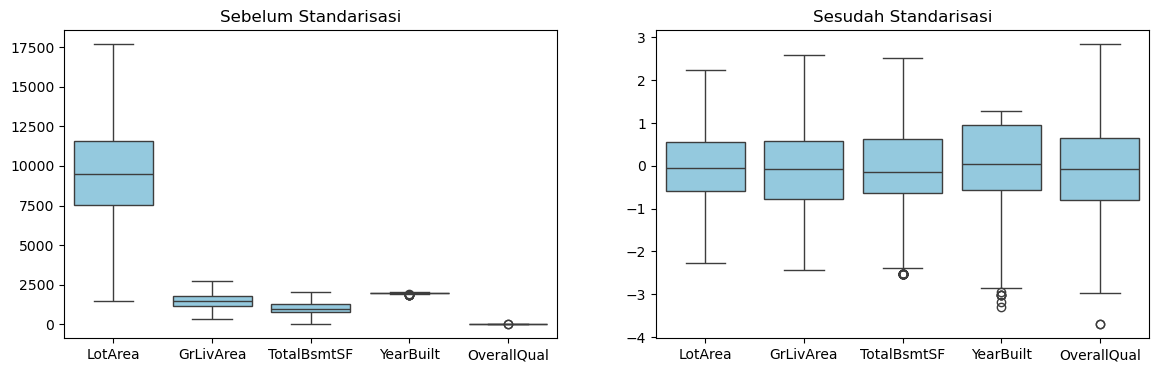

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=sebelum_scaling, color='skyblue', ax=ax[0])
ax[0].set_title('Sebelum Standarisasi')
sns.boxplot(data=df[contoh], color='skyblue', ax=ax[1])
ax[1].set_title('Sesudah Standarisasi')
plt.show()

### 4.2 One-Hot Encoding

In [20]:
print('Jumlah kolom kategorikal:', len(kolom_kategori))

df = pd.get_dummies(df, columns=kolom_kategori, dtype=int)
df.shape

Jumlah kolom kategorikal: 39


(1458, 295)

In [21]:
df.head()

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,-0.235039,-0.331112,0.658506,-0.517649,1.052959,0.880362,0.803369,0.622222,-0.288867,-0.957980,...,0,0,0,1,0,0,0,0,1,0
1,0.638123,-0.010266,-0.068293,2.177825,0.158428,-0.428115,-0.666615,1.254080,-0.288867,-0.647632,...,0,0,0,1,0,0,0,0,1,0
2,-0.060407,0.450078,0.658506,-0.517649,0.986698,0.831900,0.548372,0.111161,-0.288867,-0.300226,...,0,0,0,1,0,0,0,0,1,0
3,-0.526093,-0.024216,0.658506,-0.517649,-1.862551,-0.718888,-0.666615,-0.516051,-0.288867,-0.054726,...,0,0,0,1,1,0,0,0,0,0
4,0.870966,1.289857,1.385305,-0.517649,0.953567,0.734975,1.958356,0.503749,-0.288867,-0.170528,...,0,0,0,1,0,0,0,0,1,0


Sebanyak 39 kolom kategorikal diubah menjadi kolom biner (0/1) menggunakan one-hot encoding, sehingga jumlah kolom bertambah dari 75 menjadi 295.

## 5. Reduksi Dimensi

### 5.1 Analisis Korelasi

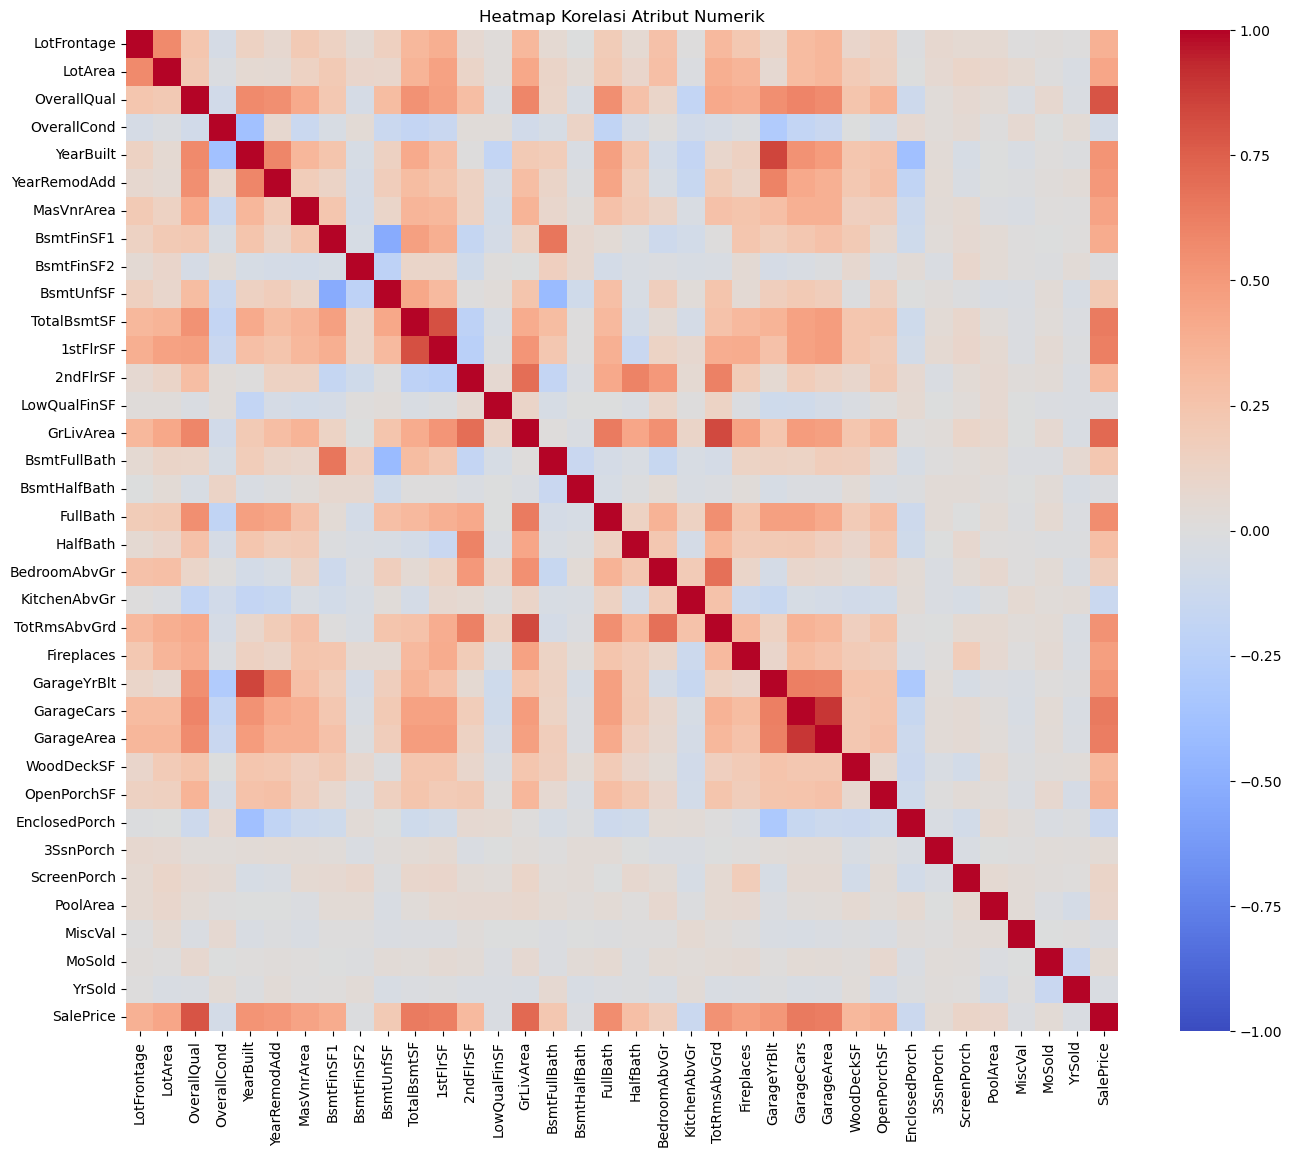

In [22]:
korelasi = df[list(kolom_numerik) + ['SalePrice']].corr()

plt.figure(figsize=(16, 13))
sns.heatmap(korelasi, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Atribut Numerik')
plt.show()

In [23]:
pasangan = []
for i in range(len(kolom_numerik)):
    for j in range(i + 1, len(kolom_numerik)):
        r = korelasi.iloc[i, j]
        if abs(r) > 0.8:
            a, b = kolom_numerik[i], kolom_numerik[j]
            pasangan.append([a, b, round(r, 3), round(korelasi.loc[a, 'SalePrice'], 3), round(korelasi.loc[b, 'SalePrice'], 3)])

pd.DataFrame(pasangan, columns=['Atribut 1', 'Atribut 2', 'Korelasi', 'Korelasi 1 - SalePrice', 'Korelasi 2 - SalePrice'])

,Atribut 1,Atribut 2,Korelasi,Korelasi 1 - SalePrice,Korelasi 2 - SalePrice
0,YearBuilt,GarageYrBlt,0.845,0.524,0.509
1,TotalBsmtSF,1stFlrSF,0.805,0.640,0.624
2,GrLivArea,TotRmsAbvGrd,0.834,0.712,0.538
3,GarageCars,GarageArea,0.894,0.641,0.633


Terdapat 4 pasang atribut dengan korelasi > 0.8. Atribut yang sangat berkorelasi membawa informasi yang hampir sama (redundan), jadi cukup dipertahankan salah satunya. Yang dibuang adalah atribut dengan korelasi lebih kecil terhadap `SalePrice`:
- `GarageYrBlt` (mirip dengan `YearBuilt`)
- `1stFlrSF` (mirip dengan `TotalBsmtSF`)
- `TotRmsAbvGrd` (mirip dengan `GrLivArea`)
- `GarageArea` (mirip dengan `GarageCars`)

In [24]:
df = df.drop(columns=['GarageYrBlt', '1stFlrSF', 'TotRmsAbvGrd', 'GarageArea'])
df.shape

(1458, 291)

### 5.2 PCA (Principal Component Analysis)

Jumlah komponen untuk 95% varians: 77


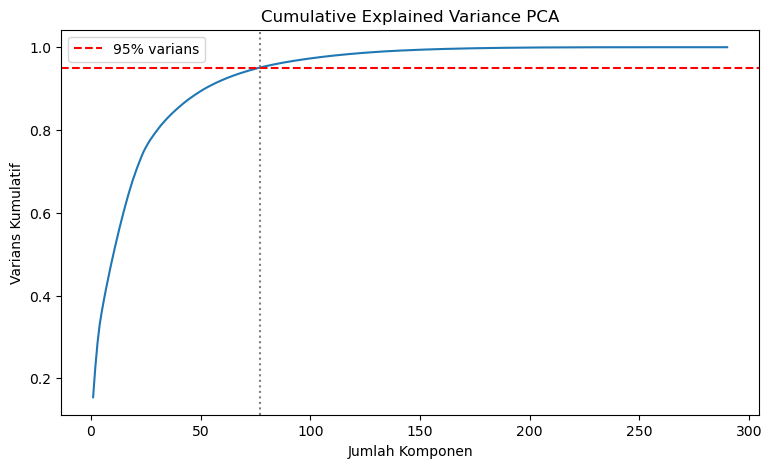

In [25]:
X = df.drop(columns='SalePrice')

pca = PCA()
pca.fit(X)
varians_kumulatif = np.cumsum(pca.explained_variance_ratio_)

n_komponen = np.argmax(varians_kumulatif >= 0.95) + 1
print('Jumlah komponen untuk 95% varians:', n_komponen)

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(varians_kumulatif) + 1), varians_kumulatif)
plt.axhline(0.95, color='red', linestyle='--', label='95% varians')
plt.axvline(n_komponen, color='gray', linestyle=':')
plt.xlabel('Jumlah Komponen')
plt.ylabel('Varians Kumulatif')
plt.title('Cumulative Explained Variance PCA')
plt.legend()
plt.show()

In [26]:
pca = PCA(n_components=n_komponen)
X_pca = pca.fit_transform(X)

print('Sebelum PCA:', X.shape)
print('Sesudah PCA:', X_pca.shape)

Sebelum PCA: (1458, 290)
Sesudah PCA: (1458, 77)


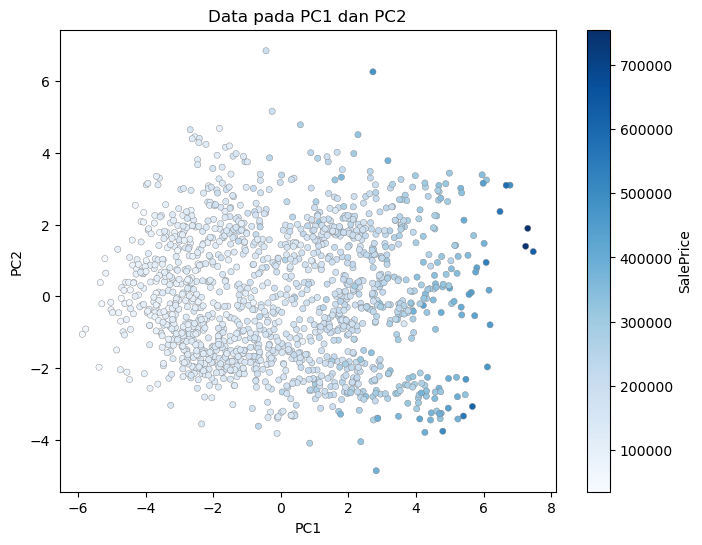

In [27]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['SalePrice'], cmap='Blues', edgecolors='gray', linewidths=0.3, s=20)
plt.colorbar(label='SalePrice')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Data pada PC1 dan PC2')
plt.show()

Dengan PCA, 290 fitur dapat diringkas menjadi 77 komponen utama dengan tetap mempertahankan 95% varians data (dimensi berkurang ±73%). Pada scatter plot terlihat rumah dengan harga tinggi cenderung berada di nilai PC1 yang besar, artinya PC1 banyak menangkap informasi yang berkaitan dengan harga rumah.

## 6. Dataset Akhir

In [28]:
print('Ukuran dataset akhir:', df.shape)
print('Total nilai hilang:', df.isnull().sum().sum())
df.head()

Ukuran dataset akhir: (1458, 291)
Total nilai hilang: 0


,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,-0.235039,-0.331112,0.658506,-0.517649,1.052959,0.880362,0.803369,0.622222,-0.288867,-0.957980,...,0,0,0,1,0,0,0,0,1,0
1,0.638123,-0.010266,-0.068293,2.177825,0.158428,-0.428115,-0.666615,1.254080,-0.288867,-0.647632,...,0,0,0,1,0,0,0,0,1,0
2,-0.060407,0.450078,0.658506,-0.517649,0.986698,0.831900,0.548372,0.111161,-0.288867,-0.300226,...,0,0,0,1,0,0,0,0,1,0
3,-0.526093,-0.024216,0.658506,-0.517649,-1.862551,-0.718888,-0.666615,-0.516051,-0.288867,-0.054726,...,0,0,0,1,1,0,0,0,0,0
4,0.870966,1.289857,1.385305,-0.517649,0.953567,0.734975,1.958356,0.503749,-0.288867,-0.170528,...,0,0,0,1,0,0,0,0,1,0


In [ ]:
df.to_csv('5054251014_Muhammad Rafie Safaraz Barus_Tugas_Praproses_Data.csv', index=False)  

## Kesimpulan

| Tahap | Hasil |
|---|---|
| Dataset awal | 1460 baris, 81 kolom |
| Hapus kolom nilai hilang > 50% dan `Id` | 5 kolom + `Id` dihapus → 75 kolom |
| Isi nilai hilang | 0 nilai hilang tersisa |
| Outlier | 2 baris anomali dihapus, 12 atribut di-capping IQR → 1458 baris |
| Standarisasi | 35 atribut numerik (mean 0, std 1) |
| One-hot encoding | 39 atribut kategorikal → 295 kolom |
| Korelasi | 4 atribut redundan dihapus → 291 kolom |
| PCA | 290 fitur → 77 komponen (95% varians) |

Dataset akhir (1458 baris × 291 kolom: 290 fitur + `SalePrice`) disimpan ke file CSV. Data tersebut sudah bersih, tidak ada nilai hilang, outlier sudah ditangani, atribut numerik sudah distandarisasi, dan atribut kategorikal sudah di-encode sehingga siap digunakan untuk model machine learning. Hasil PCA dapat digunakan langsung sebagai input model jika ingin jumlah fitur yang lebih sedikit.